<a href="https://colab.research.google.com/github/EmanuelMatiasCinel/Proyecto-Final-Data-Science/blob/main/Grupo_16_Proyecto_Data_Science_estructura_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grupo 16 - Proyecto Data Science
## Semáforo Financiero: clasificación de empresas según sus ratios contables-financieros


**Objetivo:** construir un semáforo (Aceptable / Medio / Regular) que clasifique a cada empresa comparando sus ratios financiero-contables contra la media de su propio sector, año a año.

**Fuente de datos:** "200+ Financial Indicators of US stocks (2014-2018)", Kaggle, usuario Nicolas Carbone.
URL: https://www.kaggle.com/datasets/cnic92/200-financial-indicators-of-us-stocks-20142018

**Importante:** el semáforo lo construimos nosotros a partir de los mismos ratios que después vamos a usar para describir a cada empresa. No es lo mismo que la columna `Class` que ya viene en el dataset (esa indica si el precio de la acción subió o bajó al año siguiente, y no la vamos a usar como target).

## 0. Preparación del entorno

In [39]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

Carga de datos y Diagnóstico inicial
##1. Carga y unificación de los 5 años

Se cargaron los 5 archivos (2014_Financial_Data.csv - 2018_Financial_Data.csv) y se guardaron con nombres. Cuántas filas y columnas hay y de qué tipo es cada variable. Lo hacemos solo con una de las 5 tablas para conocer su estructura.

In [40]:
#define los data frames y lee los .csv

df= pd.read_csv("2014_Financial_Data.csv")
df1= pd.read_csv("2015_Financial_Data.csv")
df2= pd.read_csv("2016_Financial_Data.csv")
df3= pd.read_csv("2017_Financial_Data.csv")
df4= pd.read_csv("2018_Financial_Data.csv")

#imprime por consola las primeras 5 filas del DataFrame
print(df.head())

# Imprime info completa del DF
print(df.info())

# Obtengo el nombre de las columnas
df.columns

  Unnamed: 0       Revenue  Revenue Growth  Cost of Revenue  Gross Profit  \
0         PG  7.440100e+10         -0.0713     3.903000e+10  3.537100e+10   
1       VIPS  3.734148e+09          1.1737     2.805625e+09  9.285226e+08   
2         KR  9.837500e+10          0.0182     7.813800e+10  2.023700e+10   
3        RAD  2.552641e+10          0.0053     1.820268e+10  7.323734e+09   
4        GIS  1.790960e+10          0.0076     1.153980e+10  6.369800e+09   

   R&D Expenses  SG&A Expense  Operating Expenses  Operating Income  \
0  0.000000e+00  2.146100e+10        2.146100e+10      1.391000e+10   
1  1.083303e+08  3.441414e+08        7.939267e+08      1.345959e+08   
2  0.000000e+00  1.519600e+10        1.751200e+10      2.725000e+09   
3  0.000000e+00  6.561162e+09        6.586482e+09      7.372520e+08   
4  0.000000e+00  3.474300e+09        3.412400e+09      2.957400e+09   

   Interest Expense  Earnings before Tax  Income Tax Expense  \
0      7.090000e+08         1.449400e+10      

Index(['Unnamed: 0', 'Revenue', 'Revenue Growth', 'Cost of Revenue',
       'Gross Profit', 'R&D Expenses', 'SG&A Expense', 'Operating Expenses',
       'Operating Income', 'Interest Expense',
       ...
       'Receivables growth', 'Inventory Growth', 'Asset Growth',
       'Book Value per Share Growth', 'Debt Growth', 'R&D Expense Growth',
       'SG&A Expenses Growth', 'Sector', '2015 PRICE VAR [%]', 'Class'],
      dtype='object', length=225)

## Corrección columnas y unificación de los 5 años

Detectamos que la primer columna donde se nombra el ticker de la empresa, aparece en blanco, es asi que Renombramos esa columna y agregamos una nueva columna que demarque el Año de la base de datos, llamada `Year`. El resto de los nombres los dejamos tal cual vienen del CSV original (con mayúsculas y espacios) porque todavía los necesitamos así para la selección de columnas del paso 3.


Se crea una sola tabla con los 5 .cvs creando una columna "anio" y nombrando la columna del nombre de las empresas como "Tiker" que se detecto como Unnamed (sin nombre).

In [41]:
anios = [2014, 2015, 2016, 2017, 2018]
tablas = []

for anio in anios:
    tabla = pd.read_csv(f"{anio}_Financial_Data.csv")
    tabla = tabla.rename(columns={"Unnamed: 0": "Ticker"})
    # la columna de variación de precio se llama '<anio+1> PRICE VAR [%]': la generalizamos
    columna_precio = [c for c in tabla.columns if "PRICE VAR" in c][0]
    tabla = tabla.rename(columns={columna_precio: "Price Var Next Year"})
    tabla["Year"] = anio
    tablas.append(tabla)

df_completo = pd.concat(tablas, ignore_index=True)
print("Filas:", df_completo.shape[0], "| Columnas:", df_completo.shape[1])
df_completo.head()

Filas: 22077 | Columnas: 226


,Ticker,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,Earnings before Tax,Income Tax Expense,Net Income - Non-Controlling int,Net Income - Discontinued ops,Net Income,Preferred Dividends,Net Income Com,EPS,EPS Diluted,Weighted Average Shs Out,Weighted Average Shs Out (Dil),Dividend per Share,Gross Margin,EBITDA Margin,EBIT Margin,...,5Y Revenue Growth (per Share),3Y Revenue Growth (per Share),10Y Operating CF Growth (per Share),5Y Operating CF Growth (per Share),3Y Operating CF Growth (per Share),10Y Net Income Growth (per Share),5Y Net Income Growth (per Share),3Y Net Income Growth (per Share),10Y Shareholders Equity Growth (per Share),5Y Shareholders Equity Growth (per Share),3Y Shareholders Equity Growth (per Share),10Y Dividend per Share Growth (per Share),5Y Dividend per Share Growth (per Share),3Y Dividend per Share Growth (per Share),Receivables growth,Inventory Growth,Asset Growth,Book Value per Share Growth,Debt Growth,R&D Expense Growth,SG&A Expenses Growth,Sector,Price Var Next Year,Class,Year
0,PG,7.440100e+10,-0.0713,3.903000e+10,3.537100e+10,0.000000e+00,2.146100e+10,2.146100e+10,1.391000e+10,7.090000e+08,1.449400e+10,2.851000e+09,1.420000e+08,-1.127000e+09,1.164300e+10,0.0,1.164300e+10,4.1900,4.010,2.705960e+09,2.705960e+09,2.448,0.4754,0.2470,0.2043,...,0.0088,-0.0182,0.0355,0.0015,0.0260,0.0603,-0.0137,0.0060,0.1442,0.0353,0.0201,0.1013,0.0834,0.0751,-0.0187,-0.0217,0.0359,0.0316,0.1228,0.0000,-0.1746,Consumer Defensive,-9.323276,0,2014
1,VIPS,3.734148e+09,1.1737,2.805625e+09,9.285226e+08,1.083303e+08,3.441414e+08,7.939267e+08,1.345959e+08,1.214869e+07,1.753823e+08,3.955957e+07,-1.431918e+07,0.000000e+00,1.358227e+08,0.0,1.358227e+08,0.2396,0.226,NaN,1.829362e+07,0.000,0.2487,0.0107,0.0502,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6484,1.7313,Consumer Defensive,-25.512193,0,2014
2,KR,9.837500e+10,0.0182,7.813800e+10,2.023700e+10,0.000000e+00,1.519600e+10,1.751200e+10,2.725000e+09,4.430000e+08,2.270000e+09,7.510000e+08,1.200000e+07,0.000000e+00,1.519000e+09,0.0,1.519000e+09,1.4700,1.450,1.033053e+09,1.028000e+09,0.307,0.2057,0.0450,0.0276,...,0.1038,0.1399,0.0889,0.0937,0.0946,0.2272,0.0906,0.1892,0.0676,0.0558,0.0789,0.0000,0.1215,0.1633,0.0618,0.0981,0.1886,0.3268,0.2738,0.0000,0.0234,Consumer Defensive,33.118297,1,2014
3,RAD,2.552641e+10,0.0053,1.820268e+10,7.323734e+09,0.000000e+00,6.561162e+09,6.586482e+09,7.372520e+08,4.245910e+08,2.502180e+08,8.040000e+05,0.000000e+00,0.000000e+00,2.494140e+08,33998000.0,2.154160e+08,4.6000,4.600,4.832628e+07,4.832628e+07,0.000,0.2869,0.0420,0.0264,...,-0.0290,-0.0230,0.0513,0.1164,0.1777,0.0480,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0211,-0.0510,-0.0189,0.1963,-0.0458,0.0000,-0.0060,Consumer Defensive,2.752291,1,2014
4,GIS,1.790960e+10,0.0076,1.153980e+10,6.369800e+09,0.000000e+00,3.474300e+09,3.412400e+09,2.957400e+09,3.024000e+08,2.707700e+09,8.833000e+08,3.690000e+07,0.000000e+00,1.824400e+09,0.0,1.824400e+09,2.9000,2.830,6.144922e+08,6.144922e+08,1.550,0.3557,0.2010,0.1681,...,0.0567,0.0773,0.0782,0.0828,0.1991,0.0776,0.0841,0.0177,0.0427,0.0623,0.0217,0.1092,0.1250,0.1144,0.0257,0.0090,0.0215,0.0274,0.1025,0.0000,-0.0220,Consumer Defensive,12.897715,1,2014


In [42]:
#comprobación

print("Dimensiones:", df_completo.shape)


print("\nRegistros por año:\n", df_completo["Year"].value_counts())

print("\nDuplicados por Ticker y Año:", df_completo.duplicated(subset=["Ticker", "Year"]).sum())


print("\nSectores únicos:\n", df_completo["Sector"].unique())

Dimensiones: (22077, 226)

Registros por año:
 Year
2017    4960
2016    4797
2018    4392
2015    4120
2014    3808
Name: count, dtype: int64

Duplicados por Ticker y Año: 0

Sectores únicos:
 ['Consumer Defensive' 'Basic Materials' 'Healthcare' 'Consumer Cyclical'
 'Industrials' 'Real Estate' 'Communication Services' 'Energy'
 'Financial Services' 'Utilities' 'Technology']


In [43]:
#guardamos el dataset unificado
df_completo.to_csv("financial_data_unificado.csv", index=False)

## 2. Diagnóstico inicial (sobre el dataset completo)

Las tres preguntas de siempre: cuántas filas y columnas, de qué tipo es cada variable, y qué tan completa está. Lo hacemos sobre las 225 columnas originales, antes de recortar, para tener una foto completa del dataset crudo.

In [44]:
# Obtengo el nombre de las columnas
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22077 entries, 0 to 22076
Columns: 226 entries, Ticker to Year
dtypes: float64(222), int64(2), object(2)
memory usage: 38.1+ MB


In [45]:
# Tipo de datos en cada columna
df_completo.dtypes

,0
Ticker,object
Revenue,float64
Revenue Growth,float64
Cost of Revenue,float64
Gross Profit,float64
...,...
SG&A Expenses Growth,float64
Sector,object
Price Var Next Year,float64
Class,int64


##Análisis de Datos Faltantes sobre Base Completa

In [46]:
# Obtengo la cantidad de datos faltantes en cada columna (NaN)
datos_faltantes = df_completo.isnull().sum()
print("Datos faltantes de cada columna", datos_faltantes)

# Obtengo el maximo valor de datos faltantes y lo guardo en la variable masnan
masnan = df_completo.isnull().sum().max()
print("Maximo valor de datos faltantes masana", masnan)

#  Calculamos el porcentaje de datos faltantes (cant. de datos faltantes/cant. de datos totales * 100)

resultado1 = (masnan / len(df_completo)) * 100

# Imprimo el maximo porcentaje de datos faltantes (porcentaje de falta de datos de la columna con mas NaN). Uso f-strings.

print(f"El porcentaje máximo de filas nulas es igual a {resultado1:.2f}%")

# Asigno el valor resultado1 al porcentaje
porcentaje = resultado1

por_str = str(porcentaje)

type(porcentaje)

type(por_str)

print(type(por_str))


Datos faltantes de cada columna Ticker                     0
Revenue                 1171
Revenue Growth          2088
Cost of Revenue         1771
Gross Profit            1207
                        ... 
SG&A Expenses Growth    2422
Sector                     0
Price Var Next Year        0
Class                      0
Year                       0
Length: 226, dtype: int64
Maximo valor de datos faltantes masana 22058
El porcentaje máximo de filas nulas es igual a 99.91%
<class 'str'>


##Análisis Datos Duplicados

In [47]:
#Analizamos la existencia de filas Duplicadas
print("Filas duplicadas:", df_completo.duplicated().sum())
print("Empresas (tickers) distintas:", df_completo["Ticker"].nunique())
print("Sectores:", df_completo["Sector"].nunique())
df_completo["Sector"].value_counts()

Filas duplicadas: 0
Empresas (tickers) distintas: 4980
Sectores: 11


,count
Sector,
Financial Services,4720
Healthcare,3305
Technology,3126
Industrials,2768
Consumer Cyclical,2471
Basic Materials,1344
Real Estate,1241
Energy,1217
Consumer Defensive,922


##Análisis de Sectores

In [48]:
#Contamos la cantidad de empresas por sector y año
tabla = df_completo.groupby(['Sector', 'Year']).size().unstack(fill_value=0)
display(tabla)

Year,2014,2015,2016,2017,2018
Sector,,,,,
Basic Materials,242,265,279,282,276
Communication Services,83,87,92,94,89
Consumer Cyclical,457,479,509,520,506
Consumer Defensive,165,175,192,199,191
Energy,221,236,246,266,248
Financial Services,660,769,1220,1247,824
Healthcare,582,628,686,718,691
Industrials,501,532,566,595,574
Real Estate,224,240,258,264,255


In [49]:
#Columnas
print("lista de columnas",df_completo.columns.tolist())

# Obtengo el promedio de la columna (Revenue-Ingresos Totales-permite calcular cuál fue la facturación promedio de las empresas por año.)

print("La facturación promedio de las empresas por año fue de: ",df_completo.groupby('Year' )["Revenue"].mean())

# Obtengo el promedio por sector y año (.unstack() para que se vizualizar bien la tabla de doble entrada y .display() genera una tabla HTML interactiva)

print("--- Facturación promedio por sector y año ---")
display(df_completo.groupby(['Sector', 'Year'])['Revenue'].mean().unstack())

lista de columnas ['Ticker', 'Revenue', 'Revenue Growth', 'Cost of Revenue', 'Gross Profit', 'R&D Expenses', 'SG&A Expense', 'Operating Expenses', 'Operating Income', 'Interest Expense', 'Earnings before Tax', 'Income Tax Expense', 'Net Income - Non-Controlling int', 'Net Income - Discontinued ops', 'Net Income', 'Preferred Dividends', 'Net Income Com', 'EPS', 'EPS Diluted', 'Weighted Average Shs Out', 'Weighted Average Shs Out (Dil)', 'Dividend per Share', 'Gross Margin', 'EBITDA Margin', 'EBIT Margin', 'Profit Margin', 'Free Cash Flow margin', 'EBITDA', 'EBIT', 'Consolidated Income', 'Earnings Before Tax Margin', 'Net Profit Margin', 'Cash and cash equivalents', 'Short-term investments', 'Cash and short-term investments', 'Receivables', 'Inventories', 'Total current assets', 'Property, Plant & Equipment Net', 'Goodwill and Intangible Assets', 'Long-term investments', 'Tax assets', 'Total non-current assets', 'Total assets', 'Payables', 'Short-term debt', 'Total current liabilities', 

Year,2014,2015,2016,2017,2018
Sector,,,,,
Basic Materials,4.217512e+09,3.281070e+09,3.014629e+09,3.512960e+09,3.924416e+09
Communication Services,2.608160e+10,1.625974e+10,1.578628e+10,1.665109e+10,1.731931e+10
Consumer Cyclical,5.692990e+09,5.631220e+09,5.689728e+09,5.815024e+09,6.306570e+09
Consumer Defensive,1.299110e+10,1.221230e+10,1.128152e+10,1.147370e+10,1.217887e+10
Energy,1.659526e+10,1.089503e+10,8.985404e+09,1.069142e+10,1.298224e+10
Financial Services,6.665841e+09,5.617539e+09,5.294325e+09,5.362532e+09,3.134432e+09
Healthcare,3.072740e+09,3.082435e+09,3.248822e+09,3.342592e+09,3.600028e+09
Industrials,3.973373e+09,3.738784e+09,3.660511e+09,3.789822e+09,4.125317e+09
Real Estate,6.695338e+08,7.304223e+08,8.364975e+08,1.006033e+09,1.184181e+09


## 3. Selección de columnas

Del dataset completo (225 columnas) nos quedamos con las que definimos por criterio financiero: valuación, rentabilidad, liquidez, endeudamiento, crecimiento y dividendos, más `Ticker`, `Year` y `Sector` para identificar cada fila.

##De la base de datos completa se utilizaran solamente las siguientes columnas:
**Valuación — "¿está cara o barata la acción?"**

•	**P/E (Price/Earnings):** cuántos años de ganancia actual hacen falta para "pagar" el precio de la acción. Bajo = parece barata (o el mercado no confía en su futuro); alto = cara (o el mercado espera que crezca mucho).

•	**P/B (Price/Book):** precio de la acción vs. el valor contable de sus activos. Sirve para ver si el mercado paga mucho más de lo que la empresa "vale en el papel".

**Rentabilidad — "¿gana plata de forma eficiente?"**

•	**ROE (Return on Equity):** por cada $1 que pusieron los accionistas, cuánta ganancia generó la empresa. Es el ratio más citado en análisis fundamental.

•	**ROA (Return on Assets):** El ROA mide cuánta ganancia genera una empresa por cada peso (o dólar) que tiene invertido en sus activos totales

•	**ROIC (Return of Invested Capital):** El ROIC mide cuánta ganancia operativa genera una empresa por cada peso (o dólar) de capital que realmente se usó para financiar el negocio

•	**Net Profit Margin:** de cada $100 que factura, cuántos terminan siendo ganancia neta (después de todos los gastos e impuestos).

**Liquidez — "¿puede pagar sus deudas de corto plazo?"**

•	**Current Ratio:** activos que puede convertir en efectivo rápido, divididos por lo que debe pagar pronto. Menor a 1 es señal de alerta (podría no cubrir sus obligaciones inmediatas).

•	**Quick Ratio:** indicador financiero que mide la capacidad de una empresa para pagar sus deudas a corto plazo usando solo sus activos más líquidos. Es más estricto y conservador porque excluye los inventarios, ya que estos tardan más tiempo en convertirse en dinero en efectivo.

•	**Free Cash Flow Margin:** % de las ventas que se convierte en caja libre (comparable entre empresas)

**Endeudamiento — "¿cuánta deuda tiene en relación a lo suyo?"**

•	**Debt to Equity:** deuda total / patrimonio de los accionistas. Alto = la empresa se financia mucho con deuda (más riesgo si suben las tasas o caen las ventas).

• **Interest Coverage:** Mide cuántas veces la ganancia operativa cubre los intereses de la deuda.

**Crecimiento — "¿está creciendo o estancada?"**

•	**Revenue Growth (YoY):** cuánto crecieron las ventas respecto al año anterior. Un solo número, no una serie — está permitido.

•	**EPS Growth (YoY):** cuánto creció la ganancia por acción respecto al año anterior.

**Dividendos y contexto**

•	**Dividend Yield:** qué % del precio de la acción se devuelve como dividendo anual.

•	**Market Cap:** tamaño de la empresa (grande/mediana/chica) — importante porque empresas grandes y chicas se comportan distinto.

•	**Sector:** la categórica clave — sin esto no se puede comparar "contra la industria" ni hacer clustering con sentido.

In [50]:
columnas_conservar = [
    # Identificadores
    "Ticker", "Year", "Sector", "Market Cap",
    # Valoración (separado del score)
    "PE ratio", "PB ratio",
    # Rentabilidad
    "ROE", "returnOnAssets", "ROIC", "Net Profit Margin", "Free Cash Flow margin",
    # Liquidez
    "Current ratio", "quickRatio",
    # Apalancamiento
    "Debt to Equity", "Interest Coverage",
    # Crecimiento
    "Revenue Growth", "EPS Growth",
    # Dividendos
    "Dividend Yield",
]
# Dropeamos todo lo que no está en columnas_deseadas y nos quedamos con df_completo recortado
df_reducido = df_completo[columnas_conservar].copy()
print("Columnas:", df_reducido.shape[1], "| Filas:", df_reducido.shape[0])
df_reducido.head()

Columnas: 18 | Filas: 22077


,Ticker,Year,Sector,Market Cap,PE ratio,PB ratio,ROE,returnOnAssets,ROIC,Net Profit Margin,Free Cash Flow margin,Current ratio,quickRatio,Debt to Equity,Interest Coverage,Revenue Growth,EPS Growth,Dividend Yield
0,PG,2014,Consumer Defensive,2.126614e+11,18.7566,3.0391,0.1664,0.5765,0.0753,0.1565,0.1359,0.9370,0.506197,0.5061,21.4429,-0.0713,0.0371,0.0311
1,VIPS,2014,Consumer Defensive,6.253200e+09,81.5526,NaN,0.3294,0.0403,0.0000,0.0364,0.0704,0.2102,0.849993,1.5093,15.4363,1.1737,1.4625,0.0000
2,KR,2014,Consumer Defensive,1.827470e+10,12.0340,3.3579,0.2821,0.1011,0.0859,0.0154,0.0126,0.8250,0.141709,2.1007,6.1242,0.0182,0.0576,0.0174
3,RAD,2014,Consumer Defensive,6.359738e+09,28.6087,0.0000,-0.1180,0.0668,0.1062,0.0098,0.0144,1.7090,0.436885,-2.7237,1.5893,0.0053,0.9167,0.0000
4,GIS,2014,Consumer Defensive,3.333006e+10,18.7034,5.1004,0.2792,0.6265,0.1041,0.1019,0.1052,0.8100,0.433465,1.3445,9.9540,0.0076,0.0140,0.0286


In [51]:
##De la base de datos completa se utilizaran solamente las siguientes columnas:
columnas_deseadas = ['Ticker', 'Year', 'PE ratio', 'PB ratio', 'ROE', 'returnOnAssets', 'ROIC',
                      'Net Profit Margin', 'Free Cash Flow margin', 'Current ratio', 'Debt to Equity', "quickRatio",
                      'Interest Coverage', 'Revenue Growth', 'EPS Growth',
                      'Dividend Yield', 'Market Cap', 'Sector']

for col in columnas_deseadas:
    print(col, '->', col in df_completo.columns)

Ticker -> True
Year -> True
PE ratio -> True
PB ratio -> True
ROE -> True
returnOnAssets -> True
ROIC -> True
Net Profit Margin -> True
Free Cash Flow margin -> True
Current ratio -> True
Debt to Equity -> True
quickRatio -> True
Interest Coverage -> True
Revenue Growth -> True
EPS Growth -> True
Dividend Yield -> True
Market Cap -> True
Sector -> True


### Traducimos las columnas al español pero mantenemos las siglas del ingles que se usan tambien en español

Recién ahora, con el dataset ya recortado, aplicamos la normalización de nombres (todo en minúscula, sin espacios, con guión bajo como separador) para trabajar más cómodos en el resto de la notebook.

In [52]:
# #def normalizar_nombre(columna):
#     """Pasa un nombre de columna a minúsculas y reemplaza separadores por guión bajo."""
#     nombre = columna.strip().lower()
#     nombre = re.sub(r"[ /&\-]+", "_", nombre)
#     return nombre

# df_reducido.columns = [normalizar_nombre(c) for c in df_reducido.columns]
# df_reducido.columns.tolist()

In [53]:
traduccion = {
    "Ticker": "ticker",
    "Year": "anio",
    "Sector": "sector",
    "Market Cap": "capitalizacion_mercado",
    "PE ratio": "pe_ratio",
    "PB ratio": "pb_ratio",
    "ROE": "roe",
    "returnOnAssets": "roa",
    "ROIC": "roic",
    "Net Profit Margin": "margen_neto",
    "Free Cash Flow margin": "margen_flujo_caja_libre",
    "Current ratio": "liquidez_corriente",
    "quickRatio": "liquidez_inmediata",
    "Debt to Equity": "deuda_patrimonio",
    "Interest Coverage": "cobertura_intereses",
    "Revenue Growth": "crecimiento_ingresos",
    "EPS Growth": "crecimiento_eps",
    "Dividend Yield": "rendimiento_dividendo",
    "Price Var Next Year": "variacion_precio_siguiente_anio",
    "Class": "clase",
}

df_reducido = df_reducido.rename(columns=traduccion)
print(df_reducido.columns.tolist())

['ticker', 'anio', 'sector', 'capitalizacion_mercado', 'pe_ratio', 'pb_ratio', 'roe', 'roa', 'roic', 'margen_neto', 'margen_flujo_caja_libre', 'liquidez_corriente', 'liquidez_inmediata', 'deuda_patrimonio', 'cobertura_intereses', 'crecimiento_ingresos', 'crecimiento_eps', 'rendimiento_dividendo']


## 4. Valores faltantes (REVISAR Y ANALIZAR MUESTRA CON GRAFICOS)

Varias de estas columnas rondan el 25% de faltantes. Antes de imputar, miren si el faltante se concentra en algún sector o año particular (como hicimos con `population` por país en la clase). Después, imputen **por sector**, que es más preciso que usar la mediana global — dos empresas de sectores muy distintos no son comparables.

In [54]:
columnas_ratio = ["pe_ratio", "pb_ratio", "roe", "returnonassets", "roic",
                  "net_profit_margin", "free_cash_flow_margin", "current_ratio", "quickRatio", "debt_to_equity",
                  "interest_coverage", "revenue_growth", "eps_growth",
                  "dividend_yield", "market_cap"]

faltantes = pd.DataFrame({
    "cantidad": df_reducido.isna().sum(),
    "porcentaje": (df_reducido.isna().mean() * 100).round(2),
})
faltantes[faltantes["cantidad"] > 0].sort_values("porcentaje", ascending=False)

,cantidad,porcentaje
roa,6535,29.60
liquidez_corriente,6516,29.51
roic,6509,29.48
pb_ratio,4977,22.54
capitalizacion_mercado,3071,13.91
liquidez_inmediata,3058,13.85
roe,2340,10.60
deuda_patrimonio,2314,10.48
margen_flujo_caja_libre,2291,10.38
pe_ratio,2248,10.18


In [55]:
# Lista de los 15 ratios financieros (excluye identificadores y columnas de validación)
columnas_ratio = [
    "capitalizacion_mercado", "pe_ratio", "pb_ratio", "roe", "roa", "roic",
    "margen_neto", "margen_flujo_caja_libre", "liquidez_corriente", "liquidez_inmediata",
    "deuda_patrimonio", "cobertura_intereses", "crecimiento_ingresos",
    "crecimiento_eps", "rendimiento_dividendo",
]

# Cuántos de esos 15 ratios le faltan a cada fila (empresa-año)
df_reducido["faltantes_en_fila"] = df_reducido[columnas_ratio].isnull().sum(axis=1)

# Distribución: ¿cuántas filas tienen 0 faltantes, 1 faltante, ..., 15 faltantes?
print("=== Distribución de faltantes por fila ===")
print(df_reducido["faltantes_en_fila"].value_counts().sort_index())
faltantes[faltantes["cantidad"] > 0].sort_values("porcentaje", ascending=False)

=== Distribución de faltantes por fila ===
faltantes_en_fila
0     12936
1      1744
2       821
3      3134
4       918
5       147
6        46
7        21
8        21
9        35
10       33
11       11
12       36
13      364
14      611
15     1199
Name: count, dtype: int64


,cantidad,porcentaje
roa,6535,29.60
liquidez_corriente,6516,29.51
roic,6509,29.48
pb_ratio,4977,22.54
capitalizacion_mercado,3071,13.91
liquidez_inmediata,3058,13.85
roe,2340,10.60
deuda_patrimonio,2314,10.48
margen_flujo_caja_libre,2291,10.38
pe_ratio,2248,10.18


## ¿Es aleatorio el faltante o se concentra en algún sector?

In [56]:
print("\n=== Promedio de faltantes por sector ===")
print(df_reducido.groupby("sector")["faltantes_en_fila"].mean().sort_values(ascending=False))


=== Promedio de faltantes por sector ===
sector
Financial Services        6.601059
Real Estate               3.679291
Communication Services    2.660674
Energy                    1.510271
Utilities                 1.198842
Consumer Defensive        1.058568
Basic Materials           1.049107
Consumer Cyclical         1.011331
Industrials               0.924494
Technology                0.570377
Healthcare                0.502874
Name: faltantes_en_fila, dtype: float64


## ¿Se concentra en algún año?

In [57]:
print("\n=== Promedio de faltantes por año ===")
print(df_reducido.groupby("anio")["faltantes_en_fila"].mean())


=== Promedio de faltantes por año ===
anio
2014    1.693277
2015    1.832039
2016    2.934334
2017    3.106250
2018    1.542805
Name: faltantes_en_fila, dtype: float64


## ¿Hay tickers puntuales con faltante total (15 de 15) en todos sus años?

In [58]:
#¿Hay tickers puntuales con faltante total (15 de 15) en todos sus años?
faltantes_por_ticker = (
    df_reducido.groupby("ticker")["faltantes_en_fila"].mean()
    .sort_values(ascending=False)
)
print("\n=== Top 10 tickers con más faltantes promedio ===")
print(faltantes_por_ticker.head(100))


=== Top 10 tickers con más faltantes promedio ===
ticker
IRR      15.0
ISD      15.0
ISG      15.0
INSI     15.0
ACGLO    15.0
         ... 
LKM      15.0
GRX      15.0
LOR      15.0
WEA      15.0
AHL      15.0
Name: faltantes_en_fila, Length: 100, dtype: float64


## Conclusión

Eliminar las filas con los 15 ratios 100% vacíos.
Completar el resto de los faltantes con la mediana del grupo sector + anio

In [59]:
# Guardamos cuántas filas había antes, para poder reportar el impacto
filas_antes = len(df_reducido)

# Eliminamos las filas donde faltan los 15 ratios (no aportan nada evaluable)
df_reducido = df_reducido[df_reducido["faltantes_en_fila"] < 15].copy()

filas_despues = len(df_reducido)

print("Filas antes:", filas_antes)
print("Filas después:", filas_despues)
print("Filas eliminadas:", filas_antes - filas_despues,
      f"({(filas_antes - filas_despues) / filas_antes * 100:.1f}% del total)")

Filas antes: 22077
Filas después: 20878
Filas eliminadas: 1199 (5.4% del total)


In [60]:
#Completa el resto de los faltantes con la mediana del grupo sector + anio
# Imputación por grupo: mediana dentro de cada combinación sector-año
for col in columnas_ratio:
    df_reducido[col] = df_reducido.groupby(["sector", "anio"])[col].transform(
        lambda serie: serie.fillna(serie.median())
    )

print("Faltantes restantes:", int(df_reducido[columnas_ratio].isnull().sum().sum()))
df_reducido.isnull().sum()

Faltantes restantes: 0


,0
ticker,0
anio,0
sector,0
capitalizacion_mercado,0
pe_ratio,0
pb_ratio,0
roe,0
roa,0
roic,0
margen_neto,0


Con esta imputación, cada empresa que tenía un ratio faltante ahora tiene el valor típico de su sector-año en ese ratio específico — es decir, para el score de salud financiera, esa empresa va a quedar "neutral" (ni particularmente sana ni en riesgo) en esa dimensión puntual, en vez de ser excluida. Vale la pena mencionarlo como supuesto metodológico en el informe final.

## 5. Outliers (Revisar)


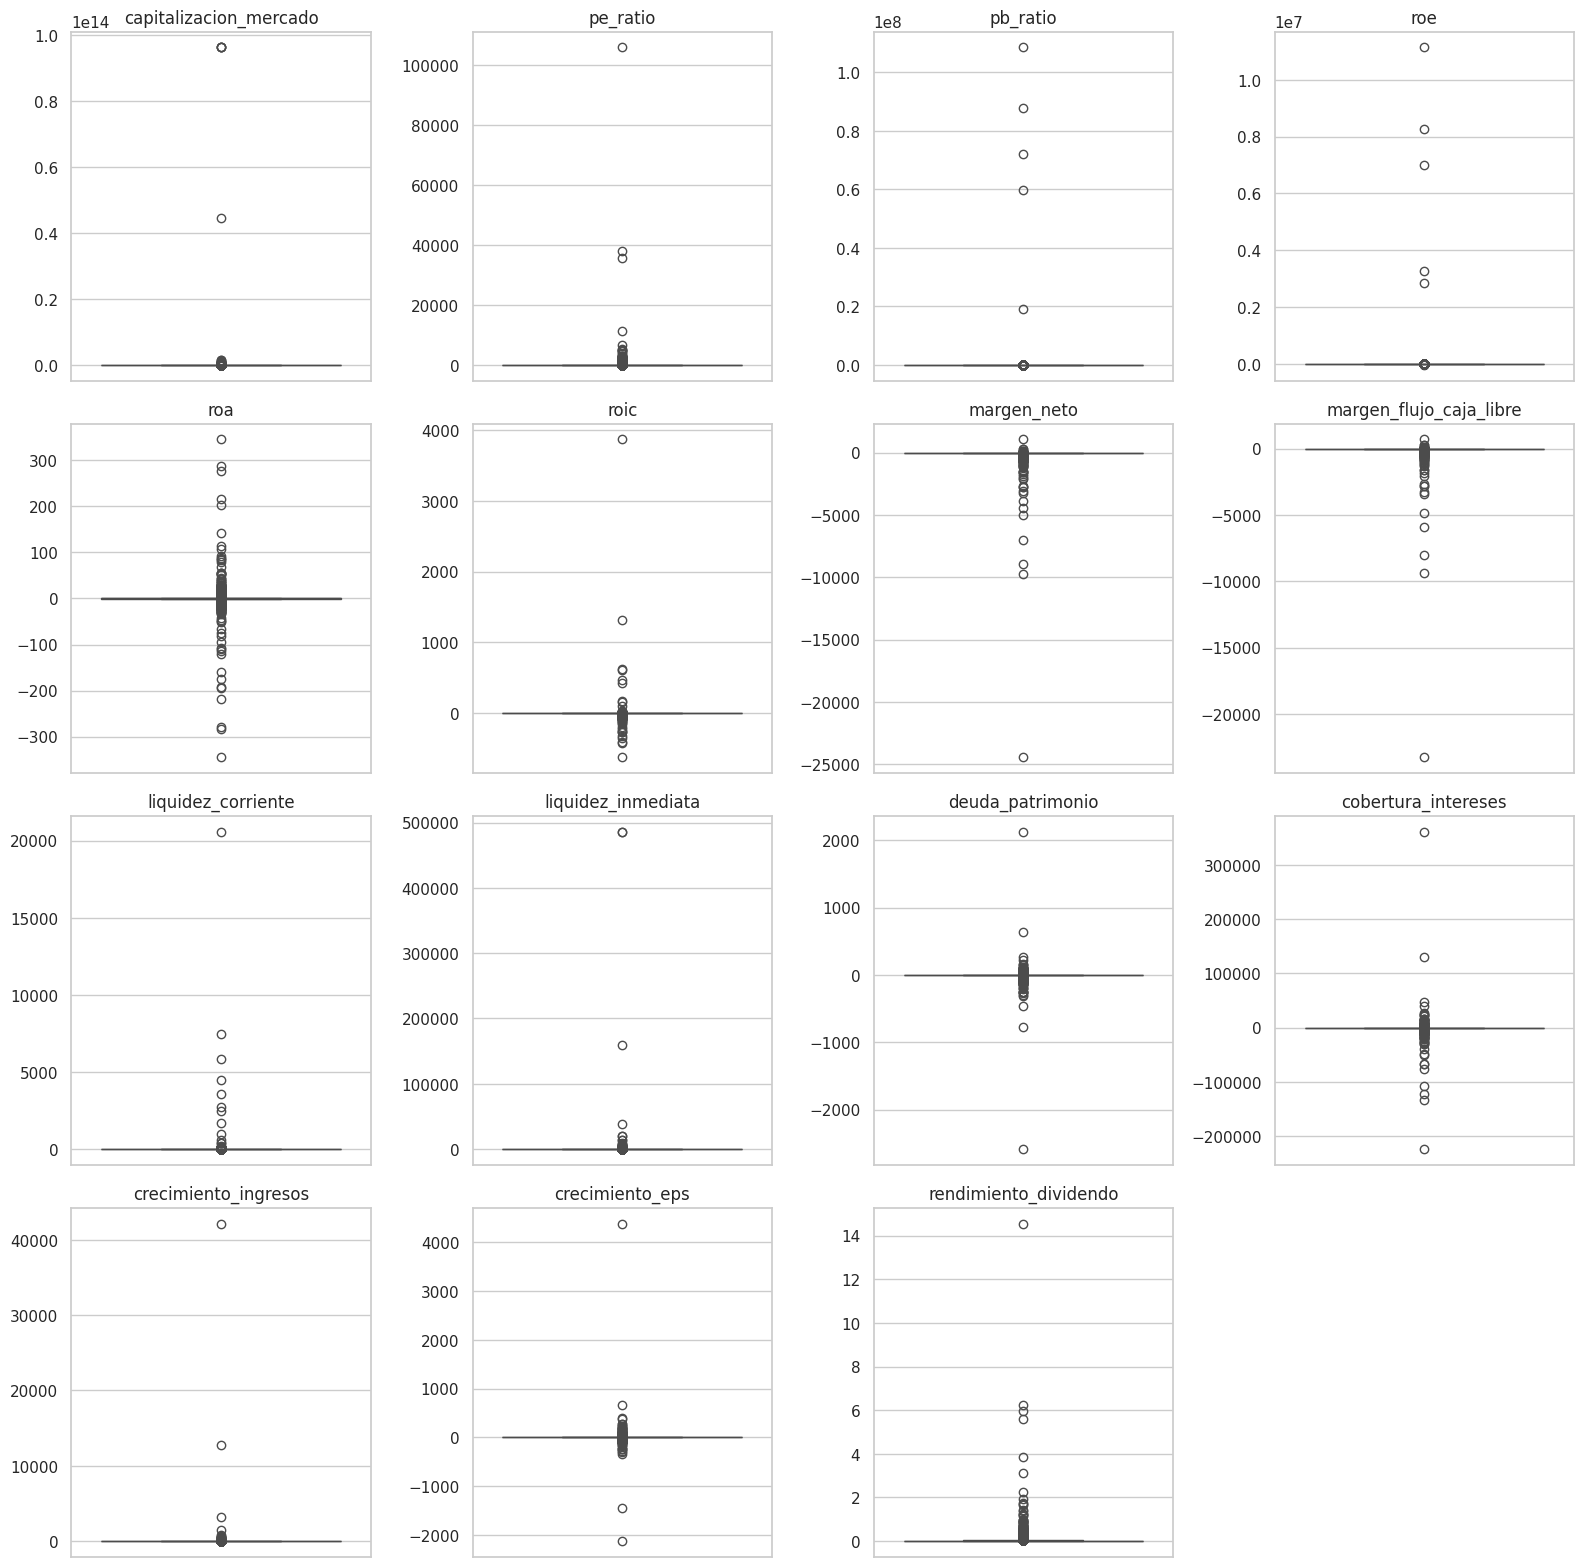

In [63]:
ncols = 4
nrows = -(-len(columnas_ratio) // ncols)  # redondeo hacia arriba
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))

for eje, columna in zip(axes.flat, columnas_ratio):
    sns.boxplot(y=df_reducido[columna], ax=eje, color="#4C72B0")
    eje.set_title(columna)
    eje.set_ylabel("")

for eje in axes.flat[len(columnas_ratio):]:
    eje.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def winsorizar(serie, percentil_bajo=0.01, percentil_alto=0.99):
    """Recorta una serie a sus percentiles bajo y alto."""
    limite_bajo = serie.quantile(percentil_bajo)
    limite_alto = serie.quantile(percentil_alto)
    return serie.clip(limite_bajo, limite_alto)

# TODO: aplicar winsorizar a cada columna de columnas_ratio (guardar en el mismo df o en columnas nuevas)
# TODO: volver a graficar los boxplots después de winsorizar y comparar contra los de arriba


## 6. Comparar cada empresa contra su sector (z-score por grupo)

Acá está el corazón del semáforo. No queremos saber si un ratio es alto o bajo en términos absolutos, sino **comparado con las demás empresas del mismo sector y año**. Para eso calculamos un z-score dentro de cada grupo `(sector, year)`.

In [ ]:
def zscore_por_grupo(serie):
    return (serie - serie.mean()) / serie.std()

for columna in columnas_ratio:
    df[f"z_{columna}"] = df.groupby(["sector", "year"])[columna].transform(zscore_por_grupo)

df[[f"z_{c}" for c in columnas_ratio]].describe().T